<a href="https://colab.research.google.com/github/mandakini-15/Titanic-Dataset/blob/main/NLP_Gourp_117.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests pandas spacy nltk matplotlib wordcloud emoji contractions psaw
!python -m spacy download en_core_web_sm

Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_details
  File "/usr/local/lib/python3.12/dist-packages/spacy/__init__.py", line 6, in <module>
    from .errors import setup_default_warnings
  File "/usr/local/lib/python3.12/dist-packages/spacy/errors.py", line 3, in <module>
    from .compat import Literal
  File "/usr/local/lib/python3.12/dist-packages/spacy/compat.py", line 5, in <module>
    from thinc.util import copy_array
  File "/usr/local/lib/python3.12/dist-packages/thinc/__init__.py", line 5, in <module>
    from .config import registry
  File "/usr/local/lib/python3.12/dist-packages/thinc/config.py", line 5, in <module>
    from .types import Decorator
  File "/usr/local/lib/python3.12/dist-packages/thinc/types.py", line 27, in <module>
    from .compat import cupy, has_cupy
  File "/usr/local/lib/python3.12/dist-packages/t

In [ ]:
import requests
import pandas as pd
import re
import string
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import emoji
import contractions
import nltk
import warnings
warnings.filterwarnings("ignore")
import spacy
from nltk.stem import PorterStemmer, SnowballStemmer
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# NLP
import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except Exception as e:
    print("spaCy model not found. Run: python -m spacy download en_core_web_sm")
    raise

In [ ]:
# NLTK corpora (download first time)
nltk.download('treebank')
nltk.download('universal_tagset')
nltk.download('punkt')

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# For HMM
from nltk.corpus import treebank
from nltk.tag import hmm

In [ ]:
import kagglehub

Dataset Import:
  Name: Pushshift Reddit Dataset via Kaggle

In [ ]:
df = pd.read_csv('Youtube01-Psy.csv')
df.head()
df.shape

(1956, 5)

Cleaning & normalization functions

In [ ]:
# Regex definitions
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
NON_ALPHANUM_RE = re.compile(r"[^a-zA-Z0-9\s]")
REPEATED_CHARS_RE = re.compile(r"(.)\1{2,}")

# Slang examples - add more as needed
SLANG_DICT = {
    "idk": "i do not know",
    "lol": "laughing out loud",
    "omg": "oh my god",
    "pls": "please",
    "plz": "please",
    "u": "you",
    "ur": "your",
    "smh": "shaking my head"
}

def clean_text(text, remove_emoji=True, remove_numbers=True, keep_hashtag_word=True):
    if not isinstance(text, str):
        return ""
    # Expand contractions
    text = contractions.fix(text)
    # Optionally remove emoji; to keep them use emoji.demojize(text)
    if remove_emoji:
        text = emoji.replace_emoji(text, replace='')
    # Remove URLs
    text = URL_RE.sub(" ", text)
    # Remove mentions (rare in YouTube comments but keep for generality)
    text = MENTION_RE.sub(" ", text)
    # Normalize hashtags - keep the word following '#'
    if keep_hashtag_word:
        text = HASHTAG_RE.sub(r"\1", text)
    else:
        text = re.sub(r"#\w+", " ", text)
    # Remove numbers optionally
    if remove_numbers:
        text = re.sub(r"\d+", " ", text)
    # Remove non-alphanumeric (keep spaces)
    text = NON_ALPHANUM_RE.sub(" ", text)
    # Reduce long repeated chars: sooo -> soo
    text = REPEATED_CHARS_RE.sub(r"\1\1", text)
    # Lowercase
    text = text.lower()
    # Expand slang dictionary
    out_tokens = []
    for tok in text.split():
        out_tokens.extend(SLANG_DICT.get(tok, tok).split())
    text = " ".join(out_tokens)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
df['clean'] = df['CONTENT'].apply(clean_text)
print("Original -> Clean (sample):\n")
for i in range(min(6, len(df))):
    print("ORIG:", df.loc[i,'CONTENT'])
    print("CLEAN:", df.loc[i,'clean'])
    print("---")

Original -> Clean (sample):

ORIG: Huh, anyway check out this you[tube] channel: kobyoshi02
CLEAN: huh anyway check out this you tube channel kobyoshi
---
ORIG: Hey guys check out my new channel and our first vid THIS IS US THE  MONKEYS!!! I'm the monkey in the white shirt,please leave a like comment  and please subscribe!!!!
CLEAN: hey guys check out my new channel and our first vid this is us the monkeys i am the monkey in the white shirt please leave a like comment and please subscribe
---
ORIG: just for test I have to say murdev.com
CLEAN: just for test i have to say murdev com
---
ORIG: me shaking my sexy ass on my channel enjoy ^_^ ﻿
CLEAN: me shaking my sexy ass on my channel enjoy
---
ORIG: watch?v=vtaRGgvGtWQ   Check this out .﻿
CLEAN: watch v vtarggvgtwq check this out
---
ORIG: Hey, check out my new website!! This site is about kids stuff. kidsmediausa  . com
CLEAN: hey check out my new website this site is about kids stuff kidsmediausa com
---


Lemmatization and Stemming for Normalizatin

In [ ]:
def lemmatize_text(text):
    """
    Lemmatizes tokens using spaCy.
    Removes stopwords/punctuation only if desired.
    """
    doc = nlp(text)
    lemmas = []

    for token in doc:
        if token.is_alpha:           # keep only words
            lemmas.append(token.lemma_)
    return lemmas

df['lemmatized'] = df['clean'].map(lemmatize_text)
df.head(5)

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS,clean,lemmatized
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1,huh anyway check out this you tube channel kob...,"[huh, anyway, check, out, this, you, tube, cha..."
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1,hey guys check out my new channel and our firs...,"[hey, guy, check, out, my, new, channel, and, ..."
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1,just for test i have to say murdev com,"[just, for, test, I, have, to, say, murdev, com]"
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1,me shaking my sexy ass on my channel enjoy,"[I, shake, my, sexy, ass, on, my, channel, enjoy]"
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1,watch v vtarggvgtwq check this out,"[watch, v, vtarggvgtwq, check, this, out]"


In [ ]:
import nltk
# Initialize stemmers
porter = PorterStemmer()
snowball = SnowballStemmer("english")
def stem_text(text, method="porter"):
    """
    Stems tokens using Porter or Snowball stemmer.
    """
    tokens = nltk.word_tokenize(text)
    stems = []

    for tok in tokens:
        if tok.isalpha():
            if method == "porter":
                stems.append(porter.stem(tok))
            elif method == "snowball":
                stems.append(snowball.stem(tok))
            else:
                raise ValueError("Choose 'porter' or 'snowball'")
    return stems

df['stemmed'] = df['clean'].map(stem_text)
df.head(5)

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS,clean,lemmatized,stemmed
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1,huh anyway check out this you tube channel kob...,"[huh, anyway, check, out, this, you, tube, cha...","[huh, anyway, check, out, thi, you, tube, chan..."
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1,hey guys check out my new channel and our firs...,"[hey, guy, check, out, my, new, channel, and, ...","[hey, guy, check, out, my, new, channel, and, ..."
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1,just for test i have to say murdev com,"[just, for, test, I, have, to, say, murdev, com]","[just, for, test, i, have, to, say, murdev, com]"
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1,me shaking my sexy ass on my channel enjoy,"[I, shake, my, sexy, ass, on, my, channel, enjoy]","[me, shake, my, sexi, ass, on, my, channel, en..."
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,1,watch v vtarggvgtwq check this out,"[watch, v, vtarggvgtwq, check, this, out]","[watch, v, vtarggvgtwq, check, thi, out]"


POS Tagging and Linguistic Exploration

In [ ]:
def pos_counts_for_doc(doc):
    """
    Given a spaCy Doc, return Counter of coarse POS tags.
    """
    c = Counter()
    for token in doc:
        # ignore punctuation/space tokens if you want; keep alpha tokens
        c[token.pos_] += 1
    return c

def pos_ratio_for_doc(doc, pos_tag):
    """
    Return ratio = (# tokens with pos_tag) / (# alpha tokens)
    """
    alpha_tokens = [t for t in doc if t.is_alpha]
    if not alpha_tokens:
        return 0.0
    pos_count = sum(1 for t in alpha_tokens if t.pos_ == pos_tag)
    return pos_count / len(alpha_tokens)

def highlight_pos_simple(text, pos_tag):
    """
    Prints tokens where token.pos_ == pos_tag wrapped as [token/POS].
    No HTML, just plain readable text.
    """
    doc = nlp(text)
    output_tokens = []

    for token in doc:
        if token.pos_ == pos_tag:
            # Highlight the matching POS tag in plain text
            output_tokens.append(f"[{token.text}/{pos_tag}]")
        else:
            output_tokens.append(token.text)

    return " ".join(output_tokens)

def find_top_posts_by_pos(df, text_col='clean', top_n=8, pos_tags=('INTJ','ADJ','PRON'), min_tokens=3):
    """
    For each pos_tag in pos_tags, compute:
      - absolute count in each post
      - ratio relative to alpha tokens in that post
    Then return top_n posts sorted by ratio (most concentrated usage).
    """
    results = {}
    # ensure the column exists
    if text_col not in df.columns:
        raise ValueError(f"Column {text_col} not found in df")

    # pre-process: compute doc objects once
    docs = list(nlp.pipe(df[text_col].astype(str).tolist(), disable=["ner"]))

    # store pos counters and ratios for each doc
    pos_counters = [pos_counts_for_doc(d) for d in docs]
    alpha_counts = [len([t for t in d if t.is_alpha]) for d in docs]

    for pos_tag in pos_tags:
        rows = []
        for i, d in enumerate(docs):
            if alpha_counts[i] < min_tokens:
                continue
            count = pos_counters[i][pos_tag]
            ratio = pos_ratio_for_doc(d, pos_tag)
            if count > 0:
                rows.append({
                    "index": i,
                    "original": df.iloc[i].get('text', ""),  # original text if exists
                    "clean": df.iloc[i][text_col],
                    "count": count,
                    "ratio": ratio,
                    "alpha_tokens": alpha_counts[i]
                })
        # sort by ratio first, then by count, descending
        rows_sorted = sorted(rows, key=lambda r: (r['ratio'], r['count']), reverse=True)
        results[pos_tag] = rows_sorted[:top_n]
    return results

def display_pos_examples_plain(results, pos_tag):
    """
    Print examples in normal plain text.
    No HTML, no color — only bracketed POS highlights.
    """
    examples = results.get(pos_tag, [])
    if not examples:
        print(f"No examples found for POS tag: {pos_tag}")
        return

    print(f"\n==============================")
    print(f"Top {len(examples)} posts for POS tag: {pos_tag}")
    print("==============================\n")

    for ex in examples:
        idx = ex['index']
        orig = ex['original'] if ex['original'] else ""
        clean = ex['clean']
        cnt = ex['count']
        ratio = ex['ratio']

        print(f"Post Index: {idx}")
        if orig:
            print("Original:", orig)
        print("Clean:", clean)
        print(f"Highlighted ({pos_tag}):", highlight_pos_simple(clean, pos_tag))
        print(f"Count: {cnt}   Ratio: {ratio:.2f}")
        print("-" * 60)

results = find_top_posts_by_pos(df, text_col='clean', top_n=6, pos_tags=('INTJ','ADJ','PRON'), min_tokens=3)
display_pos_examples_plain(results, 'INTJ')   # Interjections
display_pos_examples_plain(results, 'ADJ')    # Adjectives
display_pos_examples_plain(results, 'PRON')   # Pronouns


Top 6 posts for POS tag: INTJ

Post Index: 706
Clean: oh my god
Highlighted (INTJ): [oh/INTJ] [my/INTJ] [god/INTJ]
Count: 3   Ratio: 1.00
------------------------------------------------------------
Post Index: 878
Clean: oh my god
Highlighted (INTJ): [oh/INTJ] [my/INTJ] [god/INTJ]
Count: 3   Ratio: 1.00
------------------------------------------------------------
Post Index: 777
Clean: cool cool cool cool cool cool cool
Highlighted (INTJ): [cool/INTJ] [cool/INTJ] [cool/INTJ] [cool/INTJ] [cool/INTJ] [cool/INTJ] cool
Count: 6   Ratio: 0.86
------------------------------------------------------------
Post Index: 199
Clean: subscribe to me please please please please please please
Highlighted (INTJ): subscribe to me [please/INTJ] [please/INTJ] [please/INTJ] [please/INTJ] [please/INTJ] [please/INTJ]
Count: 6   Ratio: 0.67
------------------------------------------------------------
Post Index: 14
Clean: please like d
Highlighted (INTJ): [please/INTJ] [like/INTJ] d
Count: 2   Ratio: 0.67
-

Top POS tags: [('NOUN', 6639), ('VERB', 4752), ('PRON', 4271), ('ADP', 2896), ('DET', 2130), ('ADJ', 1869), ('PROPN', 1853), ('AUX', 1747), ('ADV', 1452), ('CCONJ', 854)]


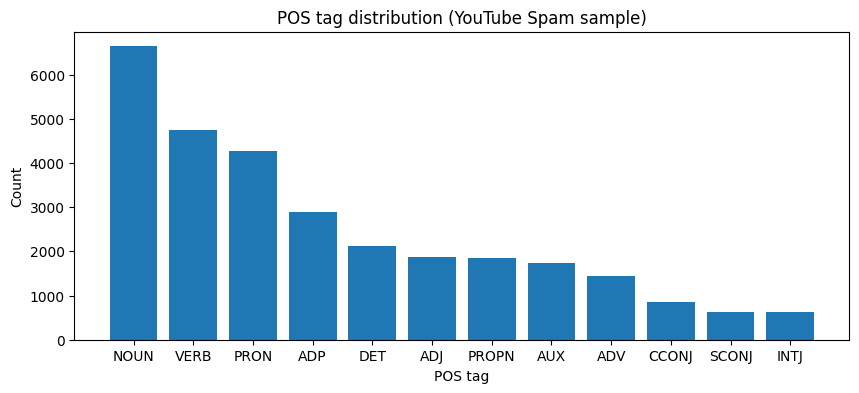

In [ ]:
def pos_counts(texts):
    c = Counter()
    for doc in nlp.pipe(texts, disable=["ner"]):
        for token in doc:
            if token.is_alpha:
                c[token.pos_] += 1
    return c

pos_counter = pos_counts(df['clean'].tolist())
print("Top POS tags:", pos_counter.most_common(10))

# Plot
plt.figure(figsize=(10,4))
labels, values = zip(*pos_counter.most_common(12))
plt.bar(labels, values)
plt.title("POS tag distribution (YouTube Spam sample)")
plt.xlabel("POS tag")
plt.ylabel("Count")
plt.show()

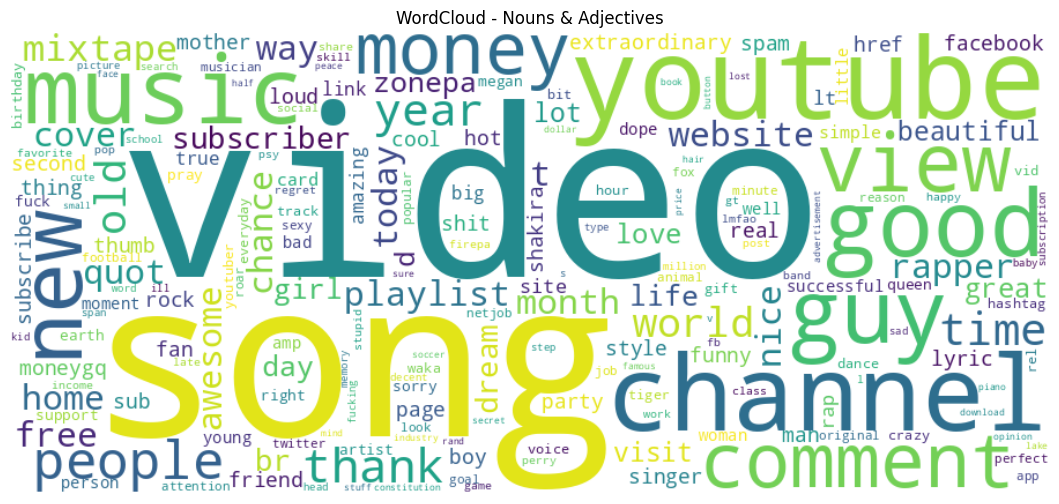

In [ ]:
# Build text from nouns and adjectives only
texts_na = []
for doc in nlp.pipe(df['clean'].tolist()):
    tokens = [tok.lemma_ for tok in doc if tok.pos_ in ('NOUN','ADJ') and not tok.is_stop]
    texts_na.append(" ".join(tokens))

wc = WordCloud(width=900, height=400, collocations=False, background_color='white').generate(" ".join(texts_na))
plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Nouns & Adjectives")
plt.show()

Syntactic pattern extraction (adj–noun, verb–object, pronoun–verb)

In [ ]:
def extract_patterns_one(text):
    doc = nlp(text)
    adj_noun, verb_obj, pron_verb = [], [], []
    for token in doc:
        # adj->noun (amod) or adj child of noun
        if token.pos_ == "ADJ":
            # check head (if it's noun)
            if token.dep_ == 'amod' and token.head.pos_ == 'NOUN':
                adj_noun.append((token.lemma_, token.head.lemma_))
            # check children for noun (rare)
            for c in token.children:
                if c.pos_ == 'NOUN':
                    adj_noun.append((token.lemma_, c.lemma_))
        # verb -> object
        if token.pos_ == "VERB":
            for c in token.children:
                if c.dep_ in ('dobj','obj') and c.pos_ == 'NOUN':
                    verb_obj.append((token.lemma_, c.lemma_))
        # pronoun -> verb (subject)
        if token.pos_ == "PRON":
            if token.dep_ in ('nsubj','nsubjpass') and token.head.pos_ == 'VERB':
                pron_verb.append((token.text.lower(), token.head.lemma_))
            for c in token.children:
                if c.pos_ == 'VERB':
                    pron_verb.append((token.text.lower(), c.lemma_))
    return adj_noun, verb_obj, pron_verb

adj_noun_all, verb_obj_all, pron_verb_all = [], [], []
for t in df['clean'].tolist():
    a, b, c = extract_patterns_one(t)
    adj_noun_all.extend(a)
    verb_obj_all.extend(b)
    pron_verb_all.extend(c)

print("Top adjective-noun pairs:", Counter(adj_noun_all).most_common(12))
print("Top verb-object pairs:", Counter(verb_obj_all).most_common(12))
print("Top pronoun-verb pairs:", Counter(pron_verb_all).most_common(12))


Top adjective-noun pairs: [(('new', 'mixtape'), 48), (('good', 'song'), 38), (('old', 'year'), 27), (('extraordinary', 'website'), 26), (('new', 'video'), 15), (('old', 'boy'), 11), (('successful', 'musician'), 10), (('few', 'second'), 10), (('old', 'rapper'), 8), (('beautiful', 'song'), 7), (('nice', 'song'), 7), (('more', 'view'), 7)]
Top verb-object pairs: [(('check', 'video'), 163), (('check', 'channel'), 64), (('love', 'song'), 47), (('make', 'money'), 39), (('check', 'playlist'), 37), (('check', 'website'), 28), (('check', 'music'), 26), (('give', 'chance'), 23), (('have', 'view'), 18), (('take', 'time'), 17), (('have', 'money'), 17), (('watch', 'video'), 15)]
Top pronoun-verb pairs: [(('i', 'love'), 101), (('i', 'm'), 56), (('i', 'have'), 51), (('i', 'know'), 46), (('i', 'make'), 42), (('i', 'like'), 36), (('you', 'make'), 34), (('i', 'do'), 32), (('i', 'want'), 29), (('you', 'like'), 29), (('you', 'want'), 28), (('i', 'appreciate'), 24)]


Combined POS + NER examples and analysis

In [ ]:
print("POS + NER examples (first 8 posts):\n")
for i in range(min(8, len(df))):
    txt = df.loc[i,'clean']
    doc = nlp(txt)
    tokens_pos = [(t.text, t.pos_, t.dep_) for t in doc]
    ents = [(e.text, e.label_) for e in doc.ents]
    print(f"Post {i} original: {df.loc[i,'CONTENT']}")
    print("Clean:", txt)
    print("Tokens+POS:", tokens_pos)
    print("Entities:", ents)
    print("------")

POS + NER examples (first 8 posts):

Post 0 original: Huh, anyway check out this you[tube] channel: kobyoshi02
Clean: huh anyway check out this you tube channel kobyoshi
Tokens+POS: [('huh', 'INTJ', 'intj'), ('anyway', 'INTJ', 'intj'), ('check', 'VERB', 'ROOT'), ('out', 'ADP', 'prt'), ('this', 'DET', 'det'), ('you', 'PRON', 'nmod'), ('tube', 'NOUN', 'compound'), ('channel', 'NOUN', 'compound'), ('kobyoshi', 'PROPN', 'dobj')]
Entities: []
------
Post 1 original: Hey guys check out my new channel and our first vid THIS IS US THE  MONKEYS!!! I'm the monkey in the white shirt,please leave a like comment  and please subscribe!!!!
Clean: hey guys check out my new channel and our first vid this is us the monkeys i am the monkey in the white shirt please leave a like comment and please subscribe
Tokens+POS: [('hey', 'INTJ', 'intj'), ('guys', 'NOUN', 'nsubj'), ('check', 'VERB', 'ROOT'), ('out', 'ADP', 'prt'), ('my', 'PRON', 'poss'), ('new', 'ADJ', 'amod'), ('channel', 'NOUN', 'dobj'), ('and', '